# KModes Clustering
This notebook will do some initial exploration on the claim_diagnosis_walk, with an attempt to add clusters using the categorical type/name/external flag data to make better sense at the claim level of the multiple diagnoses present on a particular claim.

I'll start by visualizing the diagnosis distributions.

In [ ]:
%%bigquery agg_def_diag_prev
select
  diagnosis_code
  , diagnosis_name
  --, count(distinct clm_id)  as distinct_claims
  , count(*)                as claim_prevelance
  --, count(distinct bene_id) as distinct_beneficiaries
from `spatial-earth-449020-m3.capstone_data_model.claim_diagnosis_walk`
where diagnosis_code_type = 'default'
group by diagnosis_code, diagnosis_name
order by claim_prevelance desc
limit 20

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
%%bigquery agg_def_diag_clms
select
  diagnosis_code
  , diagnosis_name
  , count(distinct clm_id)  as distinct_claims
  --, count(*)                as claim_prevelance
  --, count(distinct bene_id) as distinct_beneficiaries
from `spatial-earth-449020-m3.capstone_data_model.claim_diagnosis_walk`
where diagnosis_code_type = 'default'
group by diagnosis_code, diagnosis_name
order by distinct_claims desc
limit 20

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
%%bigquery agg_def_diag_bene
select
  diagnosis_code
  , diagnosis_name
  --, count(distinct clm_id)  as distinct_claims
  --, count(*)                as claim_prevelance
  , count(distinct bene_id) as distinct_beneficiaries
from `spatial-earth-449020-m3.capstone_data_model.claim_diagnosis_walk`
where diagnosis_code_type = 'default'
group by diagnosis_code, diagnosis_name
order by distinct_beneficiaries desc
limit 20

Query is running:   0%|          |

Downloading:   0%|          |

<Axes: xlabel='claim_prevelance', ylabel='diagnosis_name'>

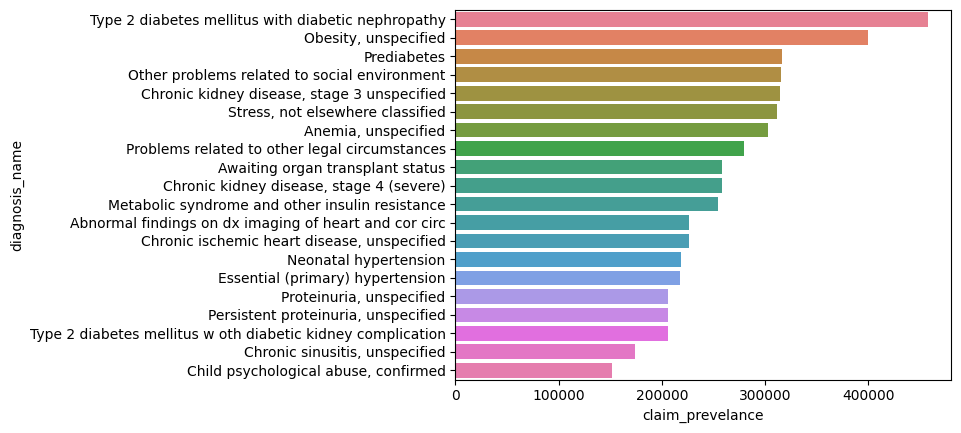

In [ ]:
import seaborn as sns
sns.barplot(agg_def_diag_prev,x='claim_prevelance',y='diagnosis_name',hue='diagnosis_name')

<Axes: xlabel='distinct_claims', ylabel='diagnosis_name'>

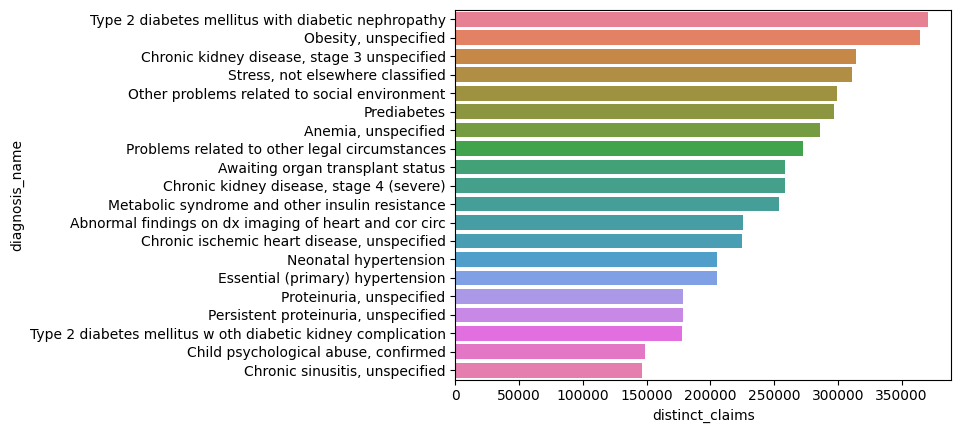

In [ ]:
sns.barplot(agg_def_diag_clms,x='distinct_claims',y='diagnosis_name',hue='diagnosis_name')

<Axes: xlabel='distinct_beneficiaries', ylabel='diagnosis_name'>

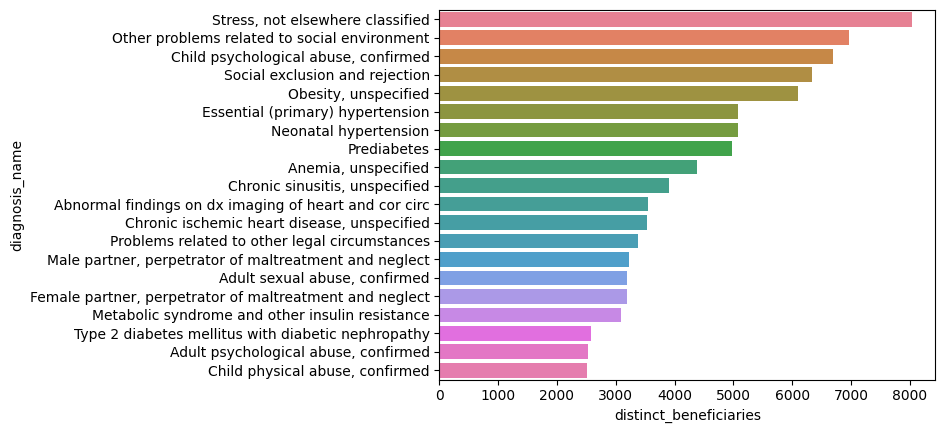

In [ ]:
sns.barplot(agg_def_diag_bene,x='distinct_beneficiaries',y='diagnosis_name',hue='diagnosis_name')

I think it is interesting to see that the distributions are different based on the different lenses of analysis. The primary lens of my predictive model will be at the claim grain, so I imagine the clusters will represent the distinct claims distribution best.

In [ ]:
%%bigquery diags_for_kmodes
select
  claim_diagnosis_key
  , diagnosis_code_type
  , diagnosis_name
  , external_flag
from `spatial-earth-449020-m3.capstone_data_model.claim_diagnosis_walk`

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
pip install kmodes

In [ ]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt

In [ ]:
diags_for_kmodes.head()

,claim_diagnosis_key,diagnosis_code_type,diagnosis_name,external_flag
0,"b'\x81\xbd\x9c3\x11C^_""\xdc\x049\xd4\xeb\xd2\x...",principal,Herpesviral gingivostomatitis and pharyngotons...,False
1,b'\xc7E\x18n\xb6`]X\xadN\tl\x88\xcd\xee\x9a\xc...,external,Fall from bed,True
2,b'\xa4\x1b\xb7\xef\xbcw\x9b\xdea\xd5\x8a\xd5\x...,default,"Sleep apnea, unspecified",False
3,b'w\x11z\x06\xe8\xd8\xc7.\xc9}\xcc\x84\x95\xcd...,default,"Sleep apnea, unspecified",False
4,b'\xd4Gh\xee\x0c1\xc9KP\x15\xd8\x85\xbdc\x11(\...,default,Other problems related to housing and economic...,False


KModes clustering finds clusters among categorical data. Because there are so many rows in this dataset, the run takes a significant amount of time. All told, finding the cluster elbows took approximately 8 hours, and a final hour was spent clustering the datapoints.

This notebook was run at different times, with historical costs recorded manually to construct the final elbow plot.

In [ ]:
#historical cost for first run - clusters 1 through 9
cost_hist = [10862202.0,10556508.0,10395249.0,9881940.0,9780789.0,9734270.0,9350000.0,8767071.0,8667480.0,8576454.0]

In [ ]:
kmode_df = diags_for_kmodes[['diagnosis_code_type','diagnosis_name','external_flag']]
kmode_df.head()

,diagnosis_code_type,diagnosis_name,external_flag
0,principal,Herpesviral gingivostomatitis and pharyngotons...,False
1,external,Fall from bed,True
2,default,"Sleep apnea, unspecified",False
3,default,"Sleep apnea, unspecified",False
4,default,Other problems related to housing and economic...,False


Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 10862202.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 10862202.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 10862202.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 10556508.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 10722513.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 10632984.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 75577, cost: 10505982.0
Init: initializing centroids

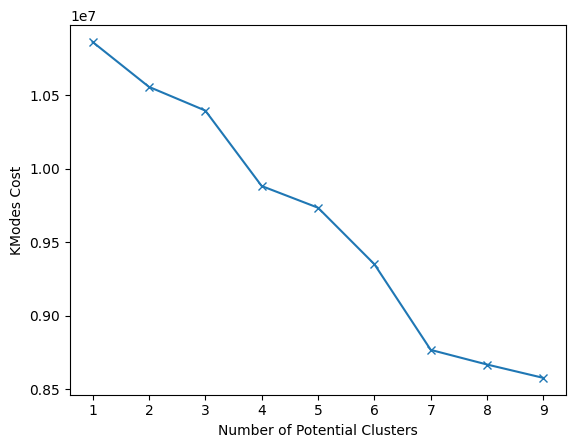

In [ ]:
#finding optimal clusters first attempt - clusters 1-9
%matplotlib inline

cost = []
k_opts = range(1,10)
for k in list(k_opts):
  kmode = KModes(n_clusters=k, init='random',n_init=3,verbose=True) #smaller initialization for a large dataset
  kmode.fit_predict(kmode_df)
  cost.append(kmode.cost_)

plt.plot(k_opts,cost,'x-')
plt.xlabel('Number of Potential Clusters')
plt.ylabel('KModes Cost')
plt.show()

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1940, cost: 7825512.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 429, cost: 8948696.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 254742, cost: 8767162.0
Run 3, iteration: 2/100, moves: 154, cost: 8767162.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 33589, cost: 8403594.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 48997, cost: 7504430.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 8149047.0
Best run was number 2
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1

ValueError: x and y must have same first dimension, but have shapes (15,) and (16,)

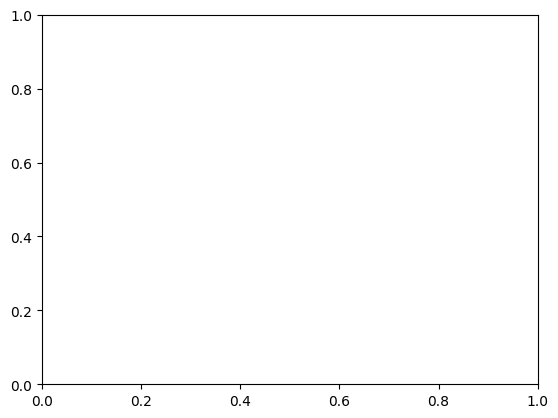

In [ ]:
#finding optimal clusters second attempt - clusters 10-15
%matplotlib inline

#keeping previous k options stored for modeling
k_list = list(k_opts)
k_new = list(range(10,16))
k_list = k_list + k_new

k_opts = range(10,16)
for k in list(k_opts):
  kmode = KModes(n_clusters=k, init='random',n_init=3,verbose=True) #smaller initialization for a large dataset
  kmode.fit_predict(kmode_df)
  cost_hist.append(kmode.cost_)

plt.plot(k_list,cost_hist,'x-')
plt.xlabel('Number of Potential Clusters')
plt.ylabel('KModes Cost')
plt.show()

In [ ]:
k_vals = list(range(1,17))
k_vals

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

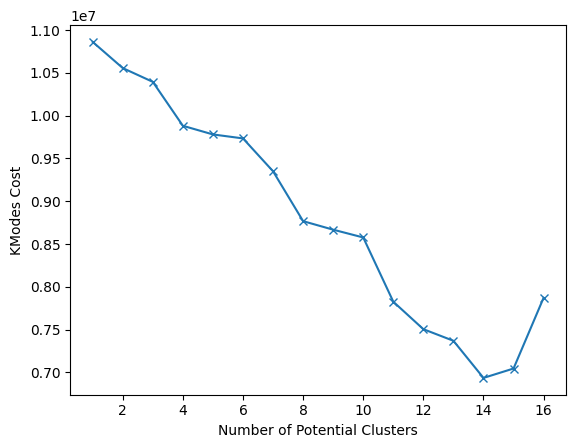

In [ ]:
%matplotlib inline

plt.plot(k_vals,cost_hist,'x-')
plt.xlabel('Number of Potential Clusters')
plt.ylabel('KModes Cost')
plt.show()

Based on clustering efforts and the length of the potential options in the diagnoses category, I will use 14 clusters (converted to binaries indicating membership) in lieu of other diagnostic indicators.

In [ ]:
cluster_14 = KModes(n_clusters=14, init='random',n_init=5,verbose=True)
clusters = cluster_14.fit_predict(kmode_df)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 447173, cost: 8309106.0
Run 1, iteration: 2/100, moves: 156, cost: 8309106.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 832710, cost: 7788879.0
Run 2, iteration: 2/100, moves: 133, cost: 7788879.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 143049, cost: 7929773.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 12782, cost: 7085768.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 645091, cost: 8161327.0
Run 5, iteration: 2/100, moves: 0, cost: 8161327.0
Best run was number 4


In [ ]:
cluster_df = pd.DataFrame(clusters, columns = ['clusters'])
cluster_df.head()

,clusters
0,0
1,7
2,0
3,0
4,0


In [ ]:
cluster_counts = cluster_df.groupby(clusters).count()
cluster_counts

,clusters
0,6601393
1,4583
2,255304
3,359637
4,305694
5,219800
6,496243
7,416630
8,315491
9,80977


In [ ]:
kmode_df['clusters'] = clusters
kmode_df.head()

,diagnosis_code_type,diagnosis_name,external_flag,clusters
0,principal,Herpesviral gingivostomatitis and pharyngotons...,False,0
1,external,Fall from bed,True,7
2,default,"Sleep apnea, unspecified",False,0
3,default,"Sleep apnea, unspecified",False,0
4,default,Other problems related to housing and economic...,False,0


I like to use PCA to visualize clusters. This is not meant to be a part of the final dataset used for predictive modeling, so I will not bother to tune the PCA decomposition before visualizing.

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


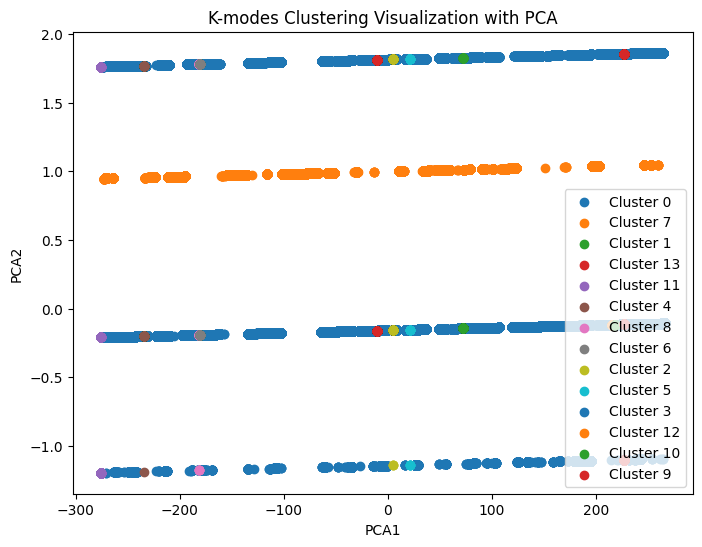

In [ ]:
#visualize data
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

encoded_data = kmode_df.drop('clusters',axis=1)

for col in encoded_data.columns:
        le = LabelEncoder()
        encoded_data[col] = le.fit_transform(encoded_data[col])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(encoded_data)

pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['clusters'] = kmode_df['clusters']

plt.figure(figsize=(8, 6))
for cluster_num in pca_df['clusters'].unique():
    subset = pca_df[pca_df['clusters'] == cluster_num]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {cluster_num}')

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K-modes Clustering Visualization with PCA')
plt.legend()
plt.show()

I want to take a quick peek at my clusters before ending the session to make sure they make sense; later, I'll use Word Clouds to visualize the totality of the cluster membership and create human-readable labels to dummify before using in the predictive modeling.

In [ ]:
cluster_3 = kmode_df[kmode_df['clusters']==3]
cluster_3.head(20)

,diagnosis_code_type,diagnosis_name,external_flag,clusters
8058198,principal,"Stress, not elsewhere classified",False,3
8058199,default,"Stress, not elsewhere classified",False,3
8058200,principal,"Stress, not elsewhere classified",False,3
8058201,default,"Stress, not elsewhere classified",False,3
8058202,default,"Stress, not elsewhere classified",False,3
8058203,default,"Stress, not elsewhere classified",False,3
8058204,default,"Stress, not elsewhere classified",False,3
8058205,default,"Stress, not elsewhere classified",False,3
8058206,default,"Stress, not elsewhere classified",False,3
8058207,default,"Stress, not elsewhere classified",False,3


In [ ]:
cluster_13 = kmode_df[kmode_df['clusters']==13]
cluster_13.head(20)

,diagnosis_code_type,diagnosis_name,external_flag,clusters
926,default,"Major depressive disorder, single episode, uns...",False,13
967,default,"Major depressive disorder, single episode, uns...",False,13
1371,principal,"Major depressive disorder, single episode, uns...",False,13
1374,default,"Major depressive disorder, single episode, uns...",False,13
1376,default,"Major depressive disorder, single episode, uns...",False,13
1378,principal,"Major depressive disorder, single episode, uns...",False,13
1379,default,"Major depressive disorder, single episode, uns...",False,13
1382,principal,"Major depressive disorder, single episode, uns...",False,13
1387,principal,"Major depressive disorder, single episode, uns...",False,13
1390,default,"Major depressive disorder, single episode, uns...",False,13


In [ ]:
cluster_0 = kmode_df[kmode_df['clusters']==0]
cluster_0.head(20)

,diagnosis_code_type,diagnosis_name,external_flag,clusters
0,principal,Herpesviral gingivostomatitis and pharyngotons...,False,0
2,default,"Sleep apnea, unspecified",False,0
3,default,"Sleep apnea, unspecified",False,0
4,default,Other problems related to housing and economic...,False,0
5,default,"Epilepsy, unsp, not intractable, without statu...",False,0
6,default,"Alcohol abuse, uncomplicated",False,0
7,default,"Acute bronchitis, unspecified",False,0
8,default,Persons encountering health services in oth ci...,False,0
9,default,"Chronic obstructive pulmonary disease, unspeci...",False,0
10,default,"Acute sinusitis, unspecified",False,0


In [ ]:
diags_for_kmodes.head()

,claim_diagnosis_key,diagnosis_code_type,diagnosis_name,external_flag
0,"b'\x81\xbd\x9c3\x11C^_""\xdc\x049\xd4\xeb\xd2\x...",principal,Herpesviral gingivostomatitis and pharyngotons...,False
1,b'\xc7E\x18n\xb6`]X\xadN\tl\x88\xcd\xee\x9a\xc...,external,Fall from bed,True
2,b'\xa4\x1b\xb7\xef\xbcw\x9b\xdea\xd5\x8a\xd5\x...,default,"Sleep apnea, unspecified",False
3,b'w\x11z\x06\xe8\xd8\xc7.\xc9}\xcc\x84\x95\xcd...,default,"Sleep apnea, unspecified",False
4,b'\xd4Gh\xee\x0c1\xc9KP\x15\xd8\x85\xbdc\x11(\...,default,Other problems related to housing and economic...,False


In [ ]:
kmode_df.head()

,diagnosis_code_type,diagnosis_name,external_flag,clusters
0,principal,Herpesviral gingivostomatitis and pharyngotons...,False,0
1,external,Fall from bed,True,7
2,default,"Sleep apnea, unspecified",False,0
3,default,"Sleep apnea, unspecified",False,0
4,default,Other problems related to housing and economic...,False,0


Finally, I'll merge the unique key back into the dataframe and load to BigQuery.

In [ ]:
#merge id back into dataframe, load to BQ
id_field = diags_for_kmodes['claim_diagnosis_key']
kmode_final = pd.merge(id_field,kmode_df,left_index=True,right_index=True)

In [ ]:
from pandas_gbq import to_gbq

project_id = 'spatial-earth-449020-m3'
table_name = 'lexie_custom_datasets.diagnosis_kmodes'

# Write DataFrame to BigQuery
to_gbq(kmode_final, table_name, project_id=project_id, if_exists='replace')

100%|██████████| 1/1 [00:00<00:00, 7371.36it/s]
